In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

In [2]:
# mount google drive to dump data (not sure if this will work for you)
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

data_dir_path='/content/gdrive/My Drive/NYP ML PROJECT/Data/'



Mounted at /content/gdrive


In [3]:
df = pd.read_csv(data_dir_path+'data_prepped.csv')

In [4]:
#View summary of dataset, check for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5954 entries, 0 to 5953
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              5954 non-null   int64  
 1   track_name        5954 non-null   object 
 2   artist_name       5954 non-null   object 
 3   track_id          5954 non-null   object 
 4   danceability      5954 non-null   float64
 5   energy            5954 non-null   float64
 6   key               5954 non-null   int64  
 7   loudness          5954 non-null   float64
 8   mode              5954 non-null   int64  
 9   speechiness       5954 non-null   float64
 10  acousticness      5954 non-null   float64
 11  instrumentalness  5954 non-null   float64
 12  liveness          5954 non-null   float64
 13  valence           5954 non-null   float64
 14  tempo             5954 non-null   float64
 15  duration_ms       5954 non-null   int64  
 16  time_signature    5954 non-null   int64  


In [5]:
df.describe()
#'mode' is either 0 or 1

,year,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,hit
count,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5954.000000,5.954000e+03,5954.000000,5954.000000
mean,2017.498488,0.567245,0.644066,5.143769,-8.275579,0.612193,0.098412,0.294143,0.208344,0.214101,0.434638,121.851336,2.316369e+05,3.893349,0.160228
std,2.875211,0.181942,0.255536,3.556247,5.353258,0.487291,0.131427,0.338522,0.343699,0.192160,0.255697,29.279011,9.761784e+04,0.459931,0.366849
min,2013.000000,0.000000,0.000020,0.000000,-43.744000,0.000000,0.000000,0.000000,0.000000,0.015400,0.000000,0.000000,1.210000e+04,0.000000,0.000000
25%,2015.000000,0.446000,0.482000,2.000000,-9.716500,0.000000,0.038200,0.009940,0.000000,0.098200,0.220000,100.007250,1.798850e+05,4.000000,0.000000
50%,2018.000000,0.582000,0.694000,5.000000,-6.832000,1.000000,0.052900,0.123500,0.000213,0.128000,0.412000,121.999500,2.156760e+05,4.000000,0.000000
75%,2020.000000,0.705000,0.855000,8.000000,-4.993000,1.000000,0.096800,0.540000,0.339750,0.274750,0.627750,139.965000,2.619768e+05,4.000000,0.000000
max,2022.000000,0.982000,1.000000,11.000000,2.822000,1.000000,0.960000,0.996000,1.000000,0.990000,0.981000,210.563000,1.800000e+06,5.000000,1.000000


In [6]:
#scaling the dataset just for the spider plot
scaler = MinMaxScaler()
numerical_cols = df.select_dtypes(include='number')
scaled_data = scaler.fit_transform(numerical_cols)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols.columns)

#df_scaled = scaler.fit_transform(df.to_numpy())
#df_scaled = pd.DataFrame(df_scaled, columns=['danceability','energy','key','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature'])

In [49]:
feature_mean = scaled_df.groupby('hit')[['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature']].mean()
feature_mean

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
hit,,,,,,,,,,,,
0.0,0.556236,0.643122,0.466036,0.752654,0.616600,0.102044,0.314926,0.246620,0.212926,0.432471,0.579983,0.775560
1.0,0.689836,0.648968,0.475891,0.808992,0.589099,0.104965,0.192590,0.007731,0.156466,0.498534,0.571934,0.794969


In [50]:
feature_mean_header = list(feature_mean.columns.values)
feature_mean_non_hit = feature_mean.loc[0, :].values.flatten().tolist()
feature_mean_hit = feature_mean.loc[1, :].values.flatten().tolist()

# add the first value back to create a closed polygon
feature_mean_header = [*feature_mean_header, feature_mean_header[0]]
feature_mean_non_hit = [*feature_mean_non_hit, feature_mean_non_hit[0]]
feature_mean_hit = [*feature_mean_hit, feature_mean_hit[0]]


In [51]:
label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(feature_mean_header))
label_loc

array([0.        , 0.52359878, 1.04719755, 1.57079633, 2.0943951 ,
       2.61799388, 3.14159265, 3.66519143, 4.1887902 , 4.71238898,
       5.23598776, 5.75958653, 6.28318531])

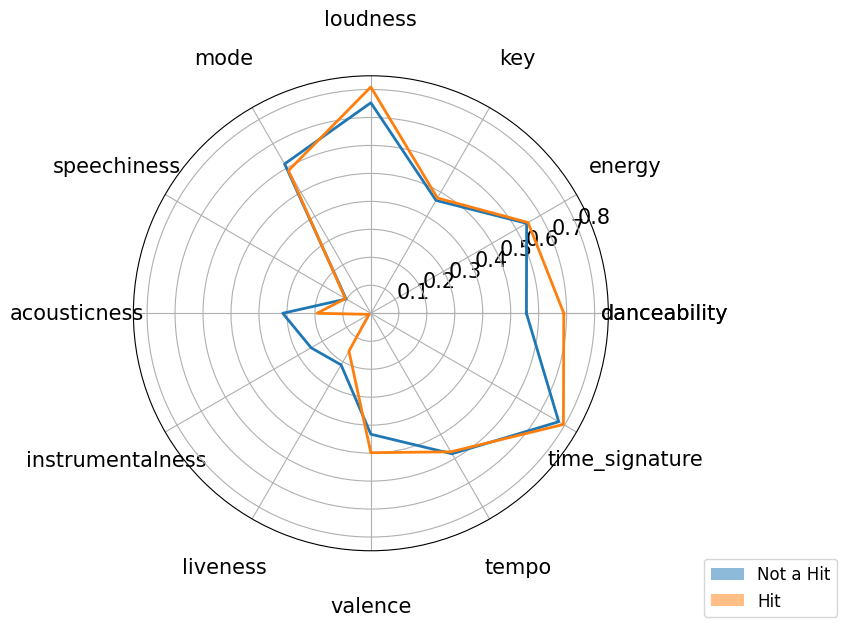

In [52]:
# a spider plot to see if there are significant differences in the mean of the audio features
fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))

ax.plot(label_loc, feature_mean_non_hit, lw=2)
ax.plot(label_loc, feature_mean_hit, lw=2)

#ax.fill(label_loc, feature_mean_non_hit, alpha=0.3)
#ax.fill(label_loc, feature_mean_non_hit, alpha=0.3)

lines, labels = plt.thetagrids(np.degrees(label_loc), labels=feature_mean_header)
ax.tick_params(axis='both', which='major', pad=30, labelsize=15)

# Create custom legend handles
non_hit_legend = Patch(facecolor='C0', alpha=0.5, label='Not a Hit')
hit_legend = Patch(facecolor='C1', alpha=0.5, label='Hit')

# Add a legend with custom position and handles
ax.legend(handles=[non_hit_legend, hit_legend],bbox_to_anchor=(1.5, 0), fontsize=12, frameon=True)

plt.tight_layout()
plt.show()
#features with clearer distinctino - loudness, danceability, valence, liveness, instrumentalness, acousticness, time signature
#features which could be discarded - speechiness, key, tempo
#note: energy's violin plot shows difference between hits vs non-hits, even though mean is similar

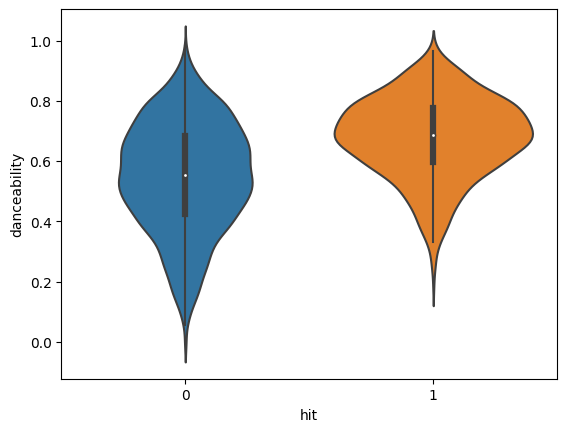

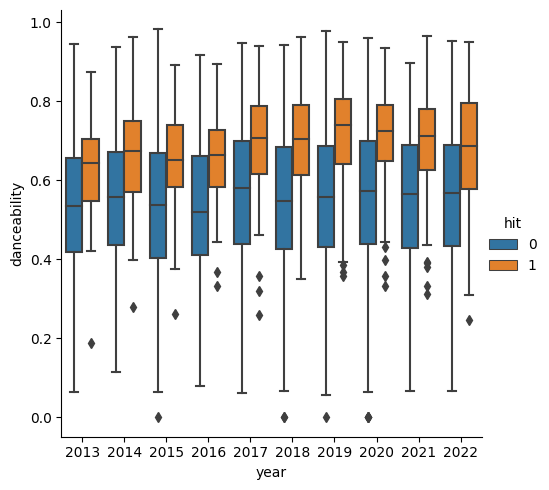

In [33]:
sns.violinplot(x='hit', y='danceability', data=df)
sns.catplot(data=df, x="year", y="danceability", hue="hit", kind="box")

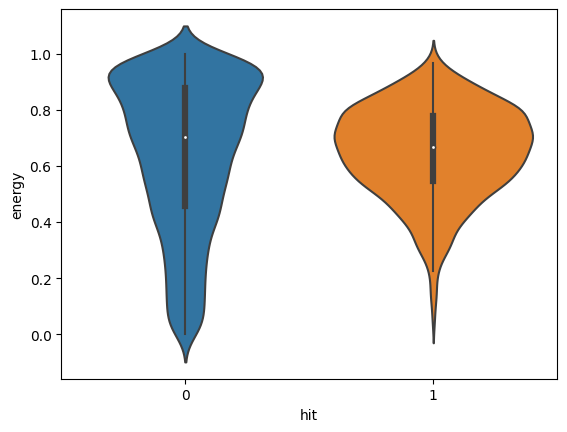

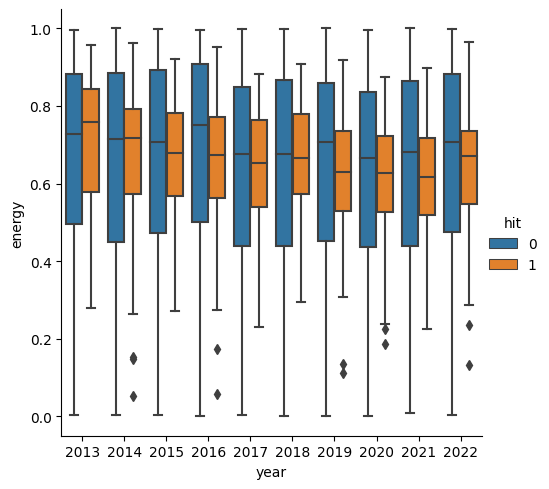

In [35]:
sns.violinplot(x='hit', y='energy', data=df)
sns.catplot(data=df, x="year", y="energy", hue="hit", kind="box")

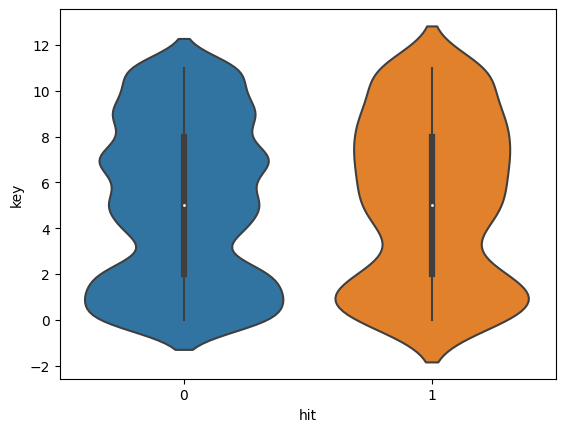

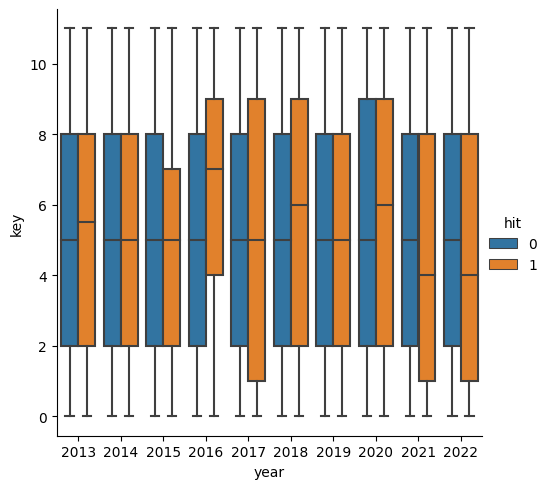

In [36]:
sns.violinplot(x='hit', y='key', data=df)
sns.catplot(data=df, x="year", y="key", hue="hit", kind="box")

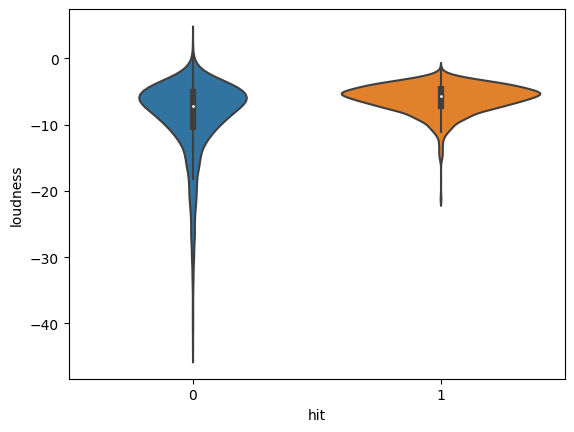

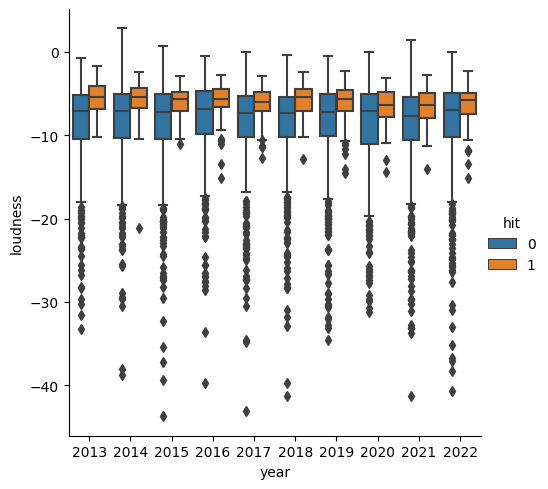

In [37]:
sns.violinplot(x='hit', y='loudness', data=df)
sns.catplot(data=df, x="year", y="loudness", hue="hit", kind="box")

year                                                         \
           count         mean       std     min     25%     50%     75%   
hit mode                                                                  
0   0     1917.0  2017.493479  2.872115  2013.0  2015.0  2017.0  2020.0   
    1     3083.0  2017.504054  2.873309  2013.0  2015.0  2018.0  2020.0   
1   0      392.0  2017.655612  2.831368  2013.0  2015.0  2018.0  2020.0   
    1      562.0  2017.375445  2.928068  2013.0  2015.0  2017.0  2020.0   

                 danceability            ... duration_ms             \
             max        count      mean  ...         75%        max   
hit mode                                 ...                          
0   0     2022.0       1917.0  0.557044  ...   276987.00  1800000.0   
    1     2022.0       3083.0  0.539496  ...   266971.50  1738053.0   
1   0     2022.0        392.0  0.691679  ...   230663.00   484147.0   
    1     2022.0        562.0  0.667473  ...   231159.75   613027.0   

         time_signature                                               
                  count      mean       std  min  25%  50%  75%  max  
hit mode                                                              
0   0            1917.0  3.898279  0.462116  0.0  4.0  4.0  4.0  5.0  
    1            3083.0  3.865066  0.508802  0.0  4.0  4.0  4.0  5.0  
1   0             392.0  3.982143  0.207746  1.0  4.0  4.0  4.0  5.0  
    1             562.0  3.969751  0.217283  3.0  4.0  4.0  4.0  5.0  

[4 rows x 104 columns]

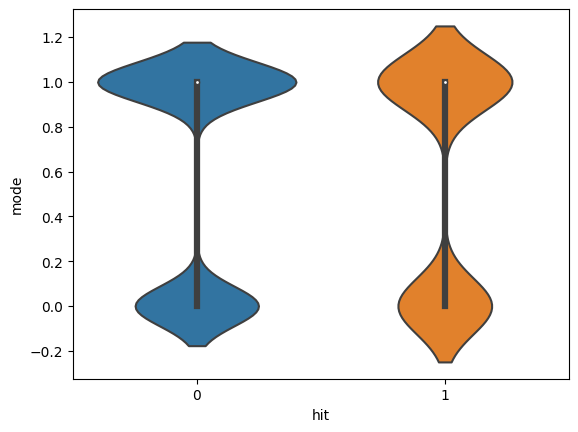

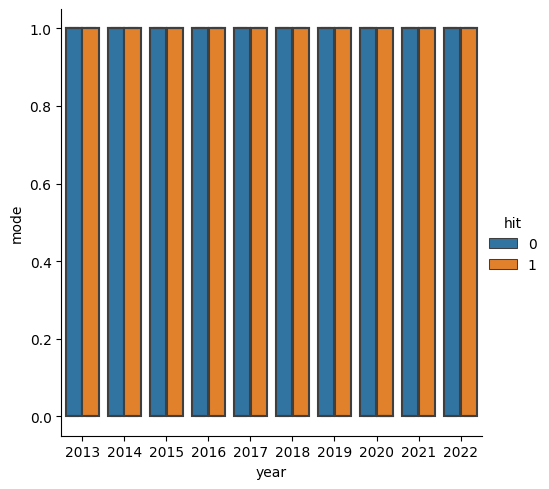

In [57]:
sns.violinplot(x='hit', y='mode', data=df)
sns.catplot(data=df, x="year", y="mode", hue="hit", kind="box")
df.groupby(['hit','mode']).describe()
#the hits have a slightly higher percentage of mode 0 (minor) - 69% compared to 62%

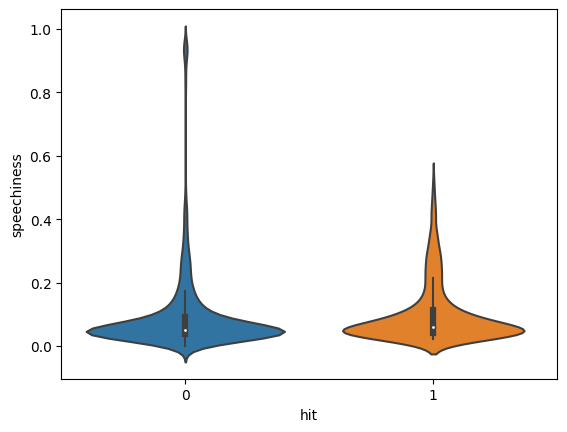

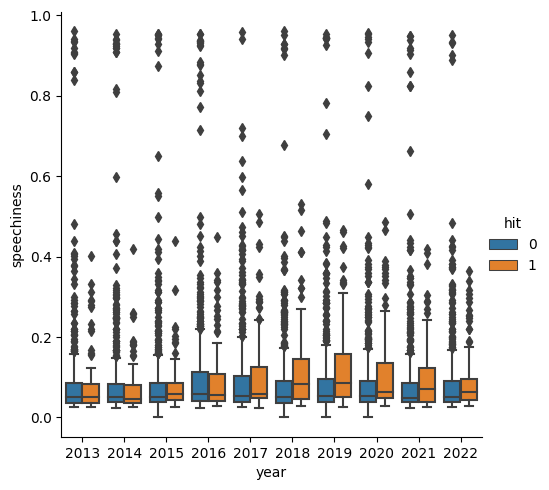

In [39]:
sns.violinplot(x='hit', y='speechiness', data=df)
sns.catplot(data=df, x="year", y="speechiness", hue="hit", kind="box")

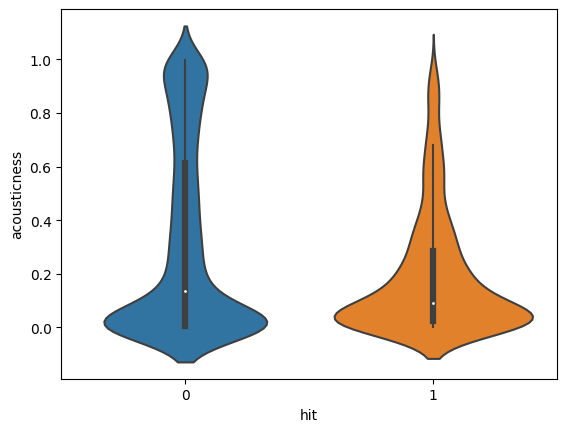

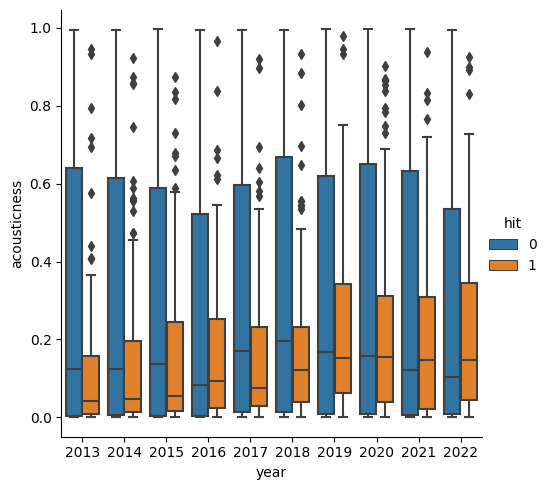

In [40]:
sns.violinplot(x='hit', y='acousticness', data=df)
sns.catplot(data=df, x="year", y="acousticness", hue="hit", kind="box")

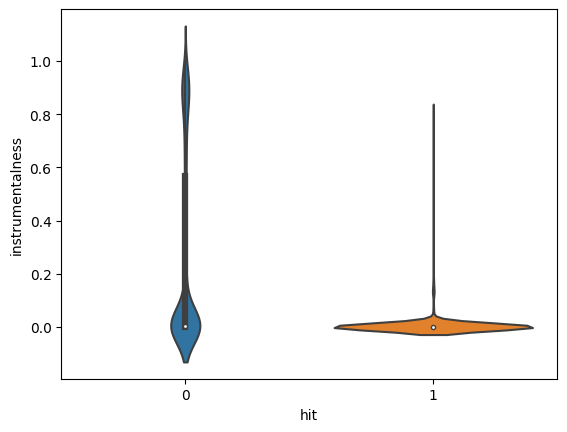

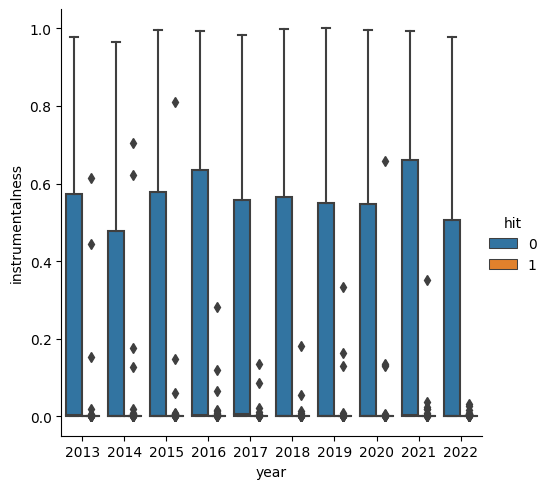

In [41]:
sns.violinplot(x='hit', y='instrumentalness', data=df)
sns.catplot(data=df, x="year", y="instrumentalness", hue="hit", kind="box")

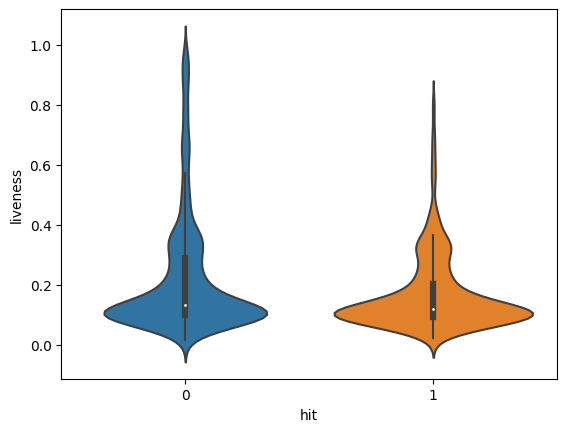

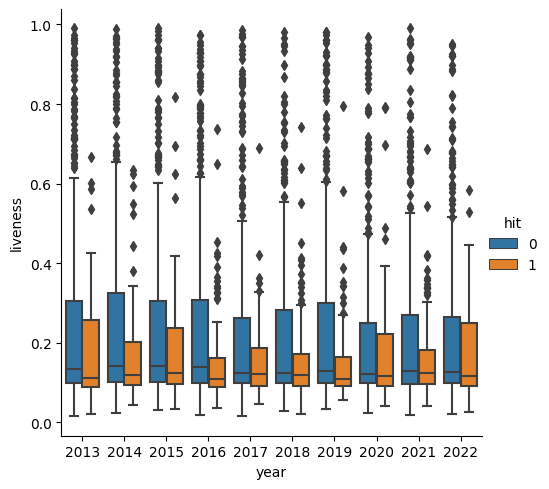

In [43]:
sns.violinplot(x='hit', y='liveness', data=df)
sns.catplot(data=df, x="year", y="liveness", hue="hit", kind="box")

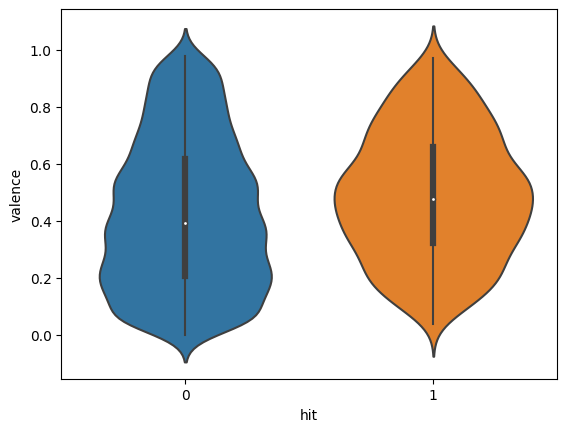

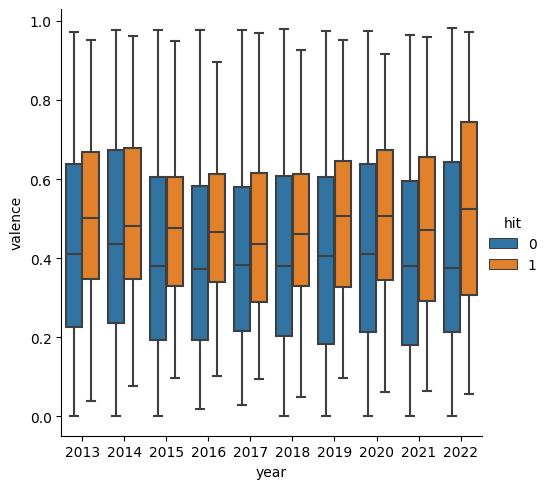

In [44]:
sns.violinplot(x='hit', y='valence', data=df)
sns.catplot(data=df, x="year", y="valence", hue="hit", kind="box")

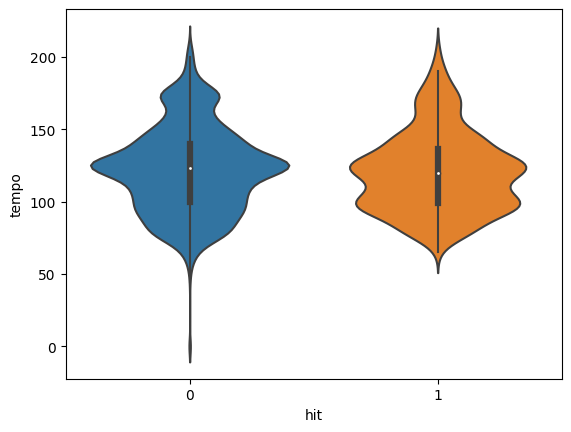

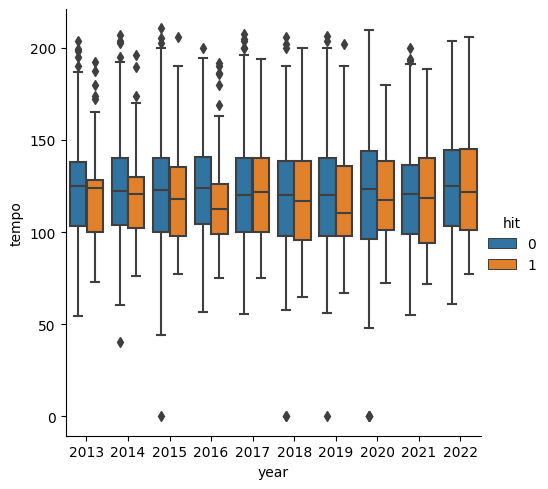

In [45]:
sns.violinplot(x='hit', y='tempo', data=df)
sns.catplot(data=df, x="year", y="tempo", hue="hit", kind="box")

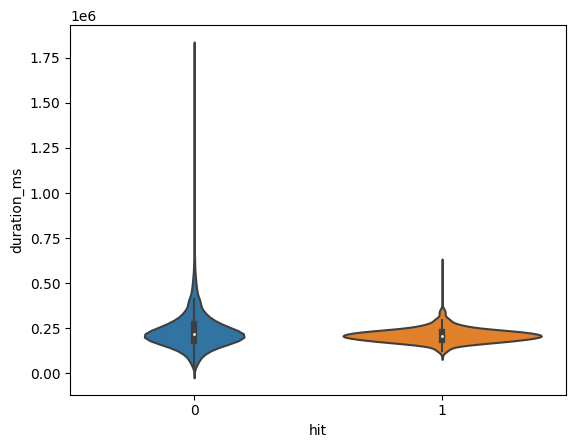

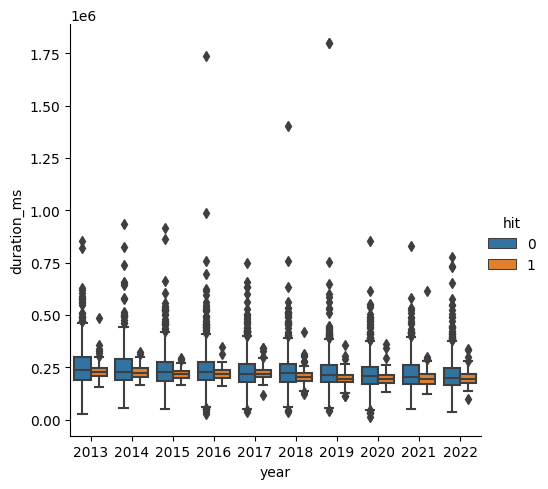

In [46]:
sns.violinplot(x='hit', y='duration_ms', data=df)
sns.catplot(data=df, x="year", y="duration_ms", hue="hit", kind="box")

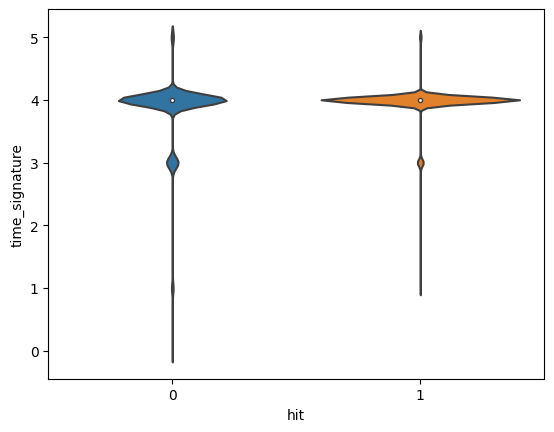

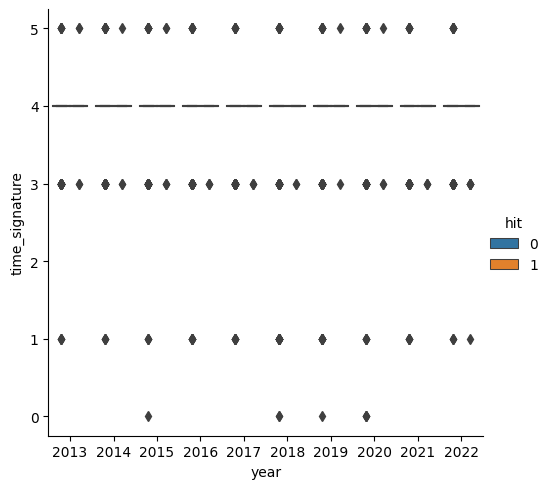

In [47]:
sns.violinplot(x='hit', y='time_signature', data=df)
sns.catplot(data=df, x="year", y="time_signature", hue="hit", kind="box")

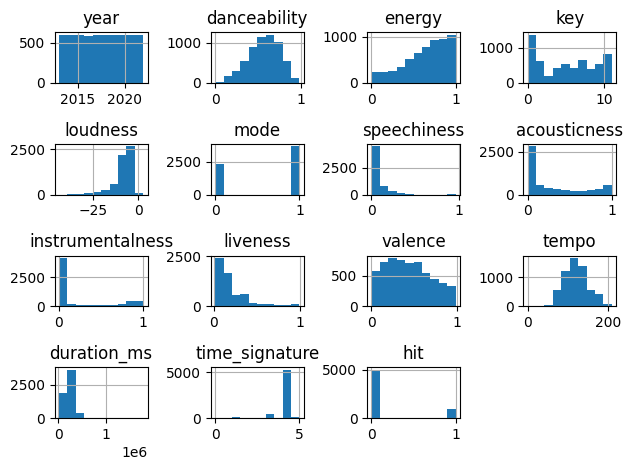

In [23]:
df.hist()
plt.tight_layout()

In [24]:
corr_matrix = df[['danceability','energy','key','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature','hit']].corr()
print(corr_matrix)



                  danceability    energy       key  loudness  speechiness  \
danceability          1.000000  0.118586  0.027971  0.292823     0.088292   
energy                0.118586  1.000000  0.040564  0.760446     0.117969   
key                   0.027971  0.040564  1.000000  0.035109     0.014543   
loudness              0.292823  0.760446  0.035109  1.000000     0.018427   
speechiness           0.088292  0.117969  0.014543  0.018427     1.000000   
acousticness         -0.205753 -0.735026 -0.031454 -0.634084     0.054826   
instrumentalness     -0.241928 -0.191007 -0.025400 -0.443345    -0.145624   
liveness             -0.139329  0.209350 -0.006377  0.067619     0.310657   
valence               0.480476  0.250382  0.036563  0.300623     0.038894   
tempo                -0.037823  0.254998  0.013286  0.231469    -0.023041   
time_signature        0.219238  0.169784  0.020468  0.205191    -0.024142   
hit                   0.264529  0.008393  0.011182  0.179779     0.007827   

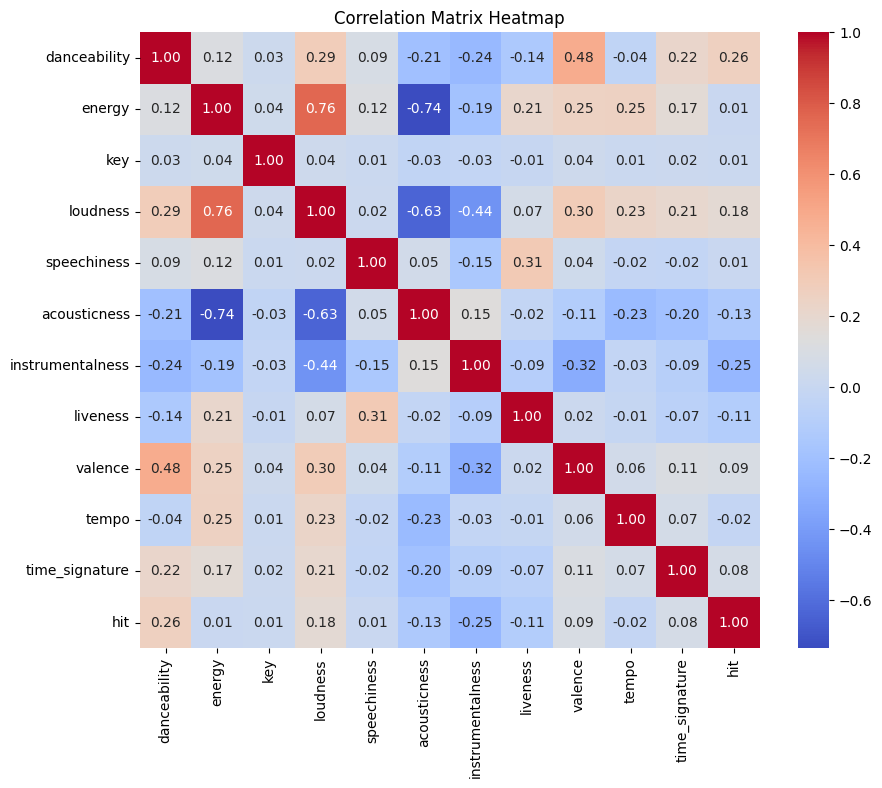

In [25]:
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [58]:
#testing the conversion of loudness
def dB_to_linear(dB_value):
    return np.power(10, dB_value / 10)

df['linear_loudness'] = df['loudness'].apply(dB_to_linear)
df['linear_loudness']

0       0.215576
1       0.169551
2       0.427957
3       0.269339
4       0.140217
          ...   
5949    0.248142
5950    0.141514
5951    0.120642
5952    0.104641
5953    0.033105
Name: linear_loudness, Length: 5954, dtype: float64